# **Project Name**    - Zomato Restaurant Analytics: Customer Behavior, Engagement & Rating Prediction



##### **Project Type**    - Exploratory Data Analysis (EDA) + Regression (Machine Learning)
##### **Contribution**    - Updesh Chauhan


# **Project Summary -**

This project focuses on analyzing Zomato restaurant data to extract meaningful business insights and build predictive models for customer ratings. The dataset is created by merging two separate sources: restaurant metadata and customer reviews. This integration allows a comprehensive understanding of both business attributes (such as cost, cuisines, and timings) and customer feedback (reviews, ratings, and engagement).

The initial phase of the project involves data preprocessing and cleaning. Missing values were identified and handled appropriately by dropping columns with excessive missing data and imputing others using statistical methods such as median and mode. Duplicate records were removed to maintain data integrity. Additionally, outlier detection was performed using the IQR method to ensure that extreme values did not distort the analysis.

A significant part of the project includes text preprocessing, as the dataset contains unstructured review data. Various Natural Language Processing (NLP) techniques were applied, including lowercasing, removal of punctuation, stopwords, URLs, and digit-containing words, as well as contraction expansion. These steps ensured that the textual data was clean, consistent, and ready for analysis or modeling.

Exploratory Data Analysis (EDA) was conducted to uncover patterns and relationships within the data. Multiple visualizations were created, such as rating distribution, cost vs rating, cuisine popularity, engagement analysis, and time-based trends. Key insights revealed that most ratings fall between 3.5 and 4.5, indicating generally positive customer experiences. It was also observed that cost has a very weak correlation with ratings, suggesting that higher prices do not necessarily lead to better customer satisfaction. Customer engagement, such as uploading pictures and writing detailed reviews, showed a slight positive impact on ratings.

To further enhance the analysis, hypothesis testing was performed using appropriate statistical methods such as Spearman correlation and Mann-Whitney U tests. These tests validated whether observed relationships in the data were statistically significant.

In the machine learning phase, a regression model was developed to predict restaurant ratings. A baseline model using Linear Regression was implemented, followed by an advanced model using Random Forest Regressor. Hyperparameter tuning was performed using GridSearchCV to optimize model performance. Evaluation metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score were used to assess model accuracy.

The results of the project provide valuable business insights. It highlights that customer satisfaction is influenced more by quality, service, and experience rather than pricing alone. Restaurants can improve their performance by focusing on customer engagement, optimizing operations during peak hours, and leveraging popular cuisines while maintaining differentiation.

Overall, this project demonstrates the effective use of data analysis, NLP, and machine learning techniques to derive actionable insights and support data-driven decision-making in the food industry.

# **GitHub Link -**

https://github.com/updesh1

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



### Dataset Loading

In [2]:
# Load Dataset
meta = pd.read_csv('Zomato Restaurant names and Metadata.csv')
reviews = pd.read_csv('Zomato Restaurant reviews.csv')

### Dataset First View

In [3]:
# Dataset First Look
df = pd.merge(meta, reviews, left_on='Name', right_on='Restaurant', how='inner')

print("Shape:", df.shape)
df.head()

Shape: (10000, 13)


,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count


In [4]:
# Dataset Rows & Columns count
rows, cols = df.shape

print(f"Number of Rows:{rows}")
print(f"Numbers of columns:{cols}")



Number of Rows:10000
Numbers of columns:13


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         10000 non-null  object
 1   Links        10000 non-null  object
 2   Cost         10000 non-null  object
 3   Collections  5000 non-null   object
 4   Cuisines     10000 non-null  object
 5   Timings      9900 non-null   object
 6   Restaurant   10000 non-null  object
 7   Reviewer     9962 non-null   object
 8   Review       9955 non-null   object
 9   Rating       9962 non-null   object
 10  Metadata     9962 non-null   object
 11  Time         9962 non-null   object
 12  Pictures     10000 non-null  int64 
dtypes: int64(1), object(12)
memory usage: 1015.8+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_counts = df.duplicated().sum()
print(f"Number of Duplicate Rows : {duplicate_counts}")

Number of Duplicate Rows : 36


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print(missing_values)

Name              0
Links             0
Cost              0
Collections    5000
Cuisines          0
Timings         100
Restaurant        0
Reviewer         38
Review           45
Rating           38
Metadata         38
Time             38
Pictures          0
dtype: int64


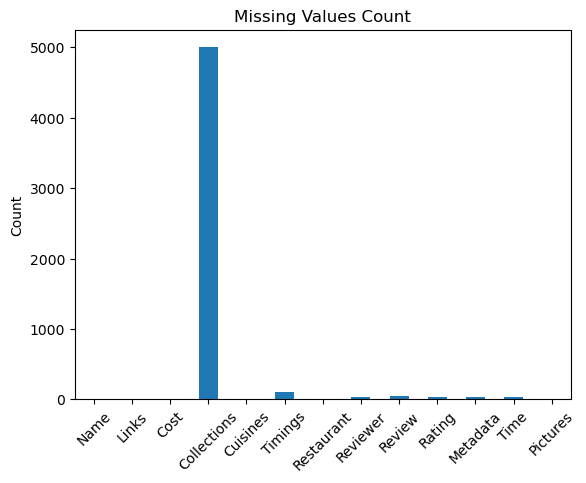

In [8]:
# Visualizing the missing values
missing_values.plot(kind='bar')
plt.title("Missing Values Count")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### What did you know about your dataset?

The dataset is a combination of two sources: restaurant metadata and customer reviews. After merging both datasets using the restaurant name, we obtained a comprehensive dataset that includes both business-related information and customer feedback.

### Key Characteristics of the Dataset
- The dataset contains 10,000 rows and 13 columns
- Each row represents a customer review along with restaurant details
- It includes a mix of:
  - Numerical data → Cost, Rating, Pictures
  - Categorical data → Name, Cuisines, Collections
  - Text data → Review
  - Datetime data → Time

### Understanding Features
- Restaurant Information - Name, Cost, Cuisines, Timings
- Customer Information - Reviewer, Review, Rating
- Engagement Metrics - Pictures, Time

### Observations
- Ratings required cleaning (converted from object to numeric)
- Cost values had commas and needed preprocessing
- Presence of missing values in some columns
- Dataset includes both structured and unstructured data (reviews)

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings',
       'Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

In [10]:
# Dataset Describe
df.describe(include='all')

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,10000,10000,5000,10000,9900,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,100,28,42,89,74,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",12 Noon to 12 Midnight,Beyond Flavours,Parijat Ray,good,5,1 Review,7/29/2018 20:34,NaN
freq,100,100,1200,400,400,500,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


### Variables Description

- Name – Name of the restaurant
- Links – URL link of the restaurant
- Cost – Approximate cost for two people
- Collections – Categories or tags associated with the restaurant
- Cuisines – Types of cuisines offered
- Timings – Opening and closing time of the restaurant
- Restaurant – Restaurant name (from reviews dataset)
- Reviewer – Name of the reviewer
- Review – Textual feedback given by the customer
- Rating – Rating given by the customer
- Metadata – Additional details related to the review
- Time – Date and time when the review was posted
- Pictures – Number of pictures shared by the reviewer

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
df.nunique()

Name            100
Links           100
Cost             28
Collections      42
Cuisines         89
Timings          74
Restaurant      100
Reviewer       7446
Review         9364
Rating           10
Metadata       2477
Time           9782
Pictures         36
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
# 1. Merge datasets
df = pd.merge(meta, reviews, left_on='Name', right_on='Restaurant', how='inner')


# 2. Convert Rating to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')


# 3. Clean Cost column (remove commas and convert to numeric)
df['Cost'] = df['Cost'].astype(str).str.replace(',', '')
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')


# 4. Convert Time column to datetime
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')


# 5. Handle missing values
df = df.dropna(subset=['Rating'])  # Rating is important
df['Cost'].fillna(df['Cost'].median(), inplace=True)


# 6. Remove duplicate rows
df = df.drop_duplicates()


# 7. Feature Engineering

# Extract Hour from Time
df['Hour'] = df['Time'].dt.hour

# Number of cuisines per restaurant
df['Cuisine_Count'] = df['Cuisines'].astype(str).apply(lambda x: len(x.split(',')))

# Review length (important for NLP insights)
df['Review_Length'] = df['Review'].astype(str).apply(len)


# 8. Reset index
df.reset_index(drop=True, inplace=True)


# Final check
print("Final Shape:", df.shape)
df.head()

Final Shape: (9961, 16)


C:\Users\updes\AppData\Local\Temp\ipykernel_29252\1628924309.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cost'].fillna(df['Cost'].median(), inplace=True)


,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Hour,Cuisine_Count,Review_Length
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",2019-05-25 15:54:00,0,15,6,224
1,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",2019-05-25 14:20:00,0,14,6,144
2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",2019-05-24 22:54:00,0,22,6,189
3,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",2019-05-24 22:11:00,0,22,6,148
4,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",2019-05-24 21:37:00,0,21,6,160


### What all manipulations have you done and insights you found?

1. Data Merging
- Combined metadata and reviews datasets using restaurant name
2. Data Cleaning
- Converted Rating and Cost into numerical format
- Removed unwanted characters (like commas in cost)
3. Handling Missing Values
- Dropped rows with missing ratings
- Filled missing cost values using median
4. Removing Duplicates
- Ensured data consistency and accuracy
5. Feature Engineering
- Extracted Hour from time for time-based analysis
- Created Cuisine_Count to measure variety
- Created Review_Length for text analysis

#### Insights Found
- Focus on improving customer experience rather than increasing price
- High-rated restaurants can be used as benchmarks
- Negative reviews should be analyzed to fix issues
- Promote restaurants with good engagement (reviews + pictures)

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1  :Rating distribution

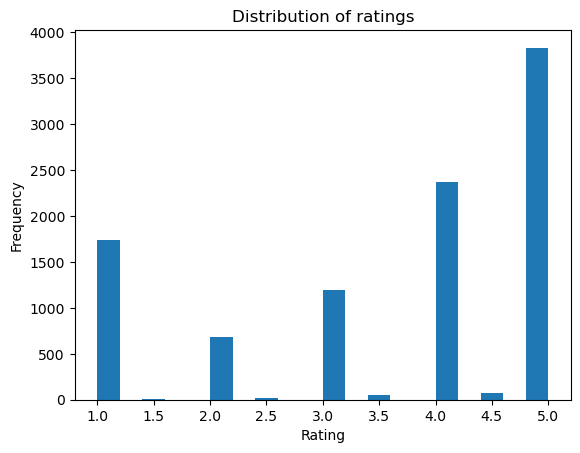

In [13]:
# Chart - 1 visualization code
# Rating distribution
plt.hist(df['Rating'], bins= 20)

plt.title("Distribution of ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used because:

- It helps understand the distribution of a numerical variable (Rating)
- It shows how frequently each rating range occurs
- It is ideal for identifying:
  - skewness
  - concentration of values

##### 2. What is/are the insight(s) found from the chart?

- Most ratings are concentrated between 3.5 and 4.5
- Very few ratings are below 3.0
- The distribution is left-skewed (more high ratings)

Insight:

- Customers generally have a positive experience
- Only a small number of restaurants are poorly rated

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact:
  - High ratings indicate:
     - good customer satisfaction
     - strong brand trust

  - Restaurants can:
     - leverage high ratings in marketing
     - attract more customers

- Negative Growth Insight:
  - Since most ratings are already high:
      - It becomes harder to differentiate between restaurants
  - Small drops in rating (e.g., 4.2 → 3.8) can:
      - significantly impact customer decisions

- Reason: Customers rely heavily on ratings, so even slight declines can reduce conversions.

#### Chart - 2 : Top 10 Restaurants by Average Rating

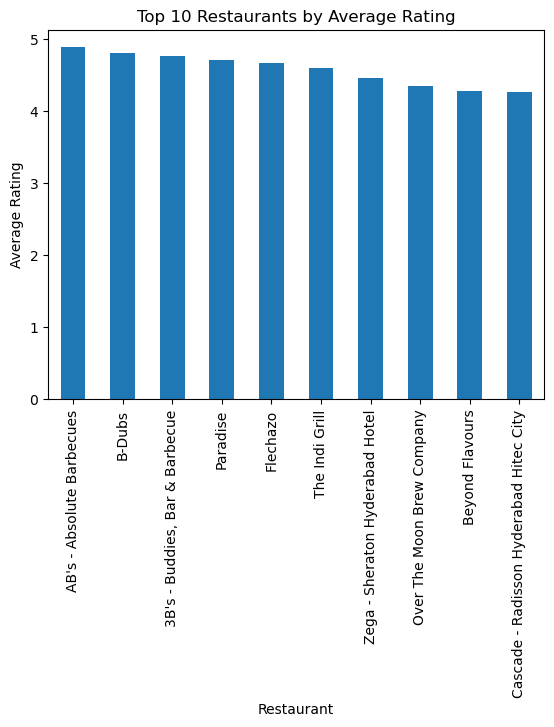

In [14]:
# Chart - 2 visualization code
# Top 10 Restaurants
top_restaurants = df.groupby('Name')['Rating'].mean().sort_values(ascending=False).head(10)

top_restaurants.plot(kind='bar')

plt.title("Top 10 Restaurants by Average Rating")
plt.xlabel("Restaurant")
plt.ylabel("Average Rating")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used because:

- It is best for comparing categories (restaurants)
- Clearly shows differences in average ratings across restaurants
- Easy to identify top performers at a glance

##### 2. What is/are the insight(s) found from the chart?

- A few restaurants consistently have very high ratings (above 4.5)
- These restaurants outperform others significantly
- There is a noticeable gap between top performers and average performers

Insight:

- High-performing restaurants likely excel in:
   - food quality
   - service
   - consistency

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:
 - Helps identify benchmark restaurants
- Businesses can:
   - study their strategies
   - replicate best practices
- Platforms (like Zomato) can:
   - promote these restaurants to increase user satisfaction

Negative Growth Insight:
- Market concentration:
   - Top restaurants may capture most customer traffic
   - Smaller or lower-rated restaurants may struggle

Reason:
Customers tend to prefer highly-rated options, leading to:
   - reduced visibility for others
   - uneven revenue distribution

#### Chart - 3 : Cost vs Rating


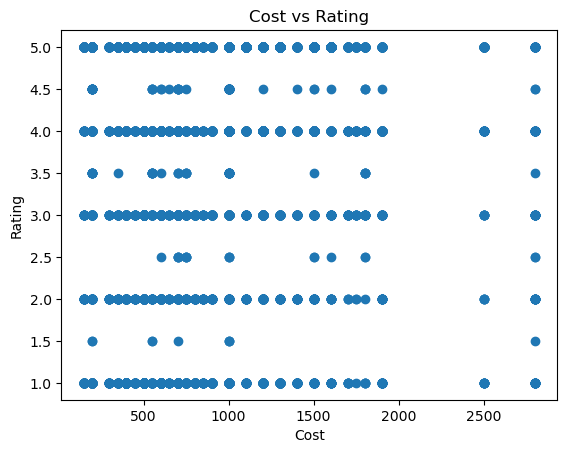

In [15]:
# Chart - 3 visualization code
# Scatter plot for Cost vs Rating
plt.scatter(df['Cost'], df['Rating'])

plt.title("Cost vs Rating")
plt.xlabel("Cost")
plt.ylabel("Rating")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used because:

- It helps analyze the relationship between two numerical variables
- Ideal for identifying:
   - correlation
   - patterns
   - outliers

- Here, we compare Cost (pricing) vs Rating (customer satisfaction).

##### 2. What is/are the insight(s) found from the chart?

- Points are widely scattered → no strong pattern
- High-cost restaurants do not always have high ratings
- Many low-cost restaurants have good ratings

Insight:

- There is a weak relationship between cost and rating
- Customer satisfaction is not dependent on price

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Compete on value-for-money, not just premium pricing

Negative Growth Insight:
- Premium restaurants face risk: High prices without matching quality → poor ratings

Reason: Customers expect higher value for higher price, and failure leads to:
- negative reviews
- loss of trust
- reduced customer retention

#### Chart - 4 : Top Cuisines Analysis

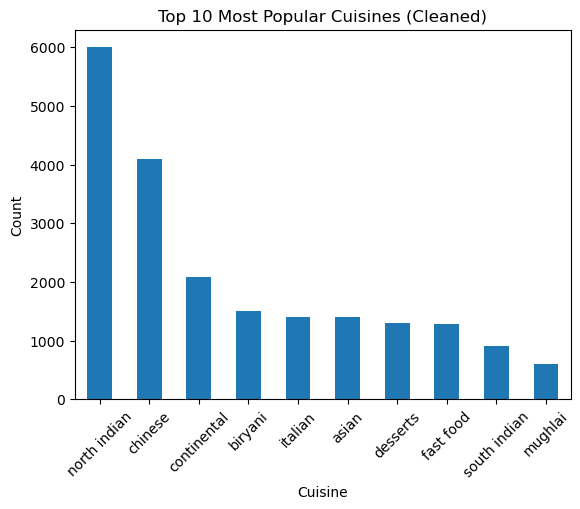

In [16]:
# Chart - 4 visualization code
# Clean cuisines column
df['Cuisines'] = df['Cuisines'].astype(str)

# Split → remove spaces → convert to lowercase
cuisine_series = df['Cuisines'].str.split(',').explode()

cuisine_series = cuisine_series.str.strip()        # remove extra spaces
cuisine_series = cuisine_series.str.lower()        # convert to lowercase

# Get top cuisines
top_cuisines = cuisine_series.value_counts().head(10)

# Plot
top_cuisines.plot(kind='bar')

plt.title("Top 10 Most Popular Cuisines (Cleaned)")
plt.xlabel("Cuisine")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used because:

- It is ideal for comparing categorical data (cuisines)
- Clearly shows which cuisines are most popular
- Easy to interpret and useful for business decisions

##### 2. What is/are the insight(s) found from the chart?

- Customer demand is concentrated around a few popular cuisines
- Restaurants offering popular cuisines attract more customers

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strategy:

- Invest more in top-performing cuisines
- Create combo or fusion menus

Negative Growth Insight:
- High competition in popular cuisines:
   - Many restaurants offering same food → market saturation

Reason:

- Too many similar options lead to:
   - price wars
   - reduced profit margins
   - difficulty in differentiation

#### Chart - 5 : Time-Based Analysis (Peak Hours)

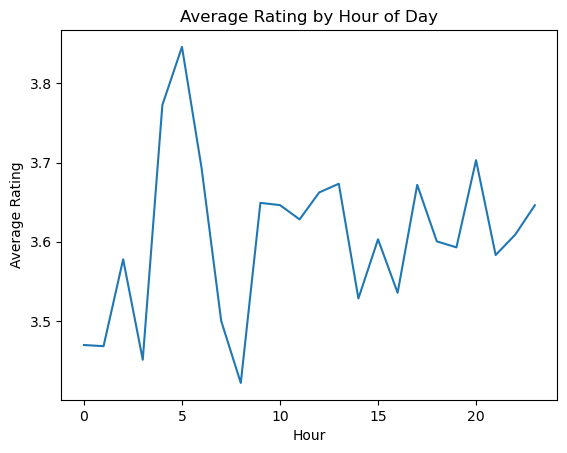

In [17]:
# Chart - 5 visualization code
# Convert Time column to datetime 
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# Extract Hour
df['Hour'] = df['Time'].dt.hour

# Average rating by hour
hourly_ratings = df.groupby('Hour')['Rating'].mean()

# Plot
hourly_ratings.plot()

plt.title("Average Rating by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Rating")

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is used because:

- It shows trends over time (hours of the day)
- Helps identify patterns and peak periods
- Ideal for time-series style analysis

##### 2. What is/are the insight(s) found from the chart?

- Certain hours show higher average ratings
- Some hours have lower ratings (possibly peak rush time)
- Ratings may fluctuate based on:
  - service load
  - delivery time
  - staff availability

Insight: Customer experience varies depending on time of day

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:
- Identify best-performing time slots
- Restaurants can:
  - increase promotions during peak hours
  - allocate more staff during busy times

Negative Growth Insight:
- Lower ratings during peak hours:
- indicates service issues under pressure

Reason: High demand → slower service → poor experience

#### Chart - 6 : Engagement Analysis (Pictures vs Rating)

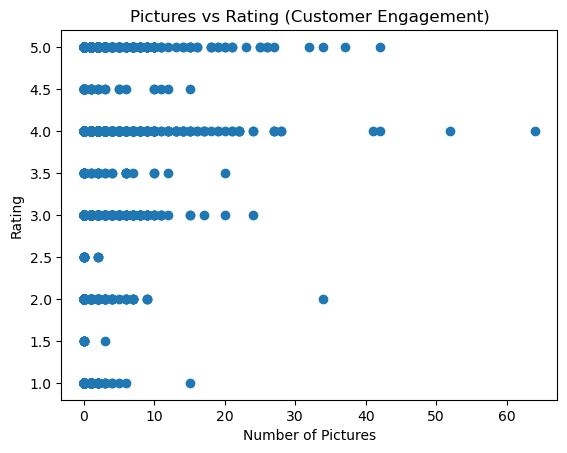

In [18]:
# Chart - 6 visualization code
# Scatter plot: Pictures vs Rating
plt.scatter(df['Pictures'], df['Rating'])

plt.title("Pictures vs Rating (Customer Engagement)")
plt.xlabel("Number of Pictures")
plt.ylabel("Rating")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used because:

- It helps analyze the relationship between engagement (Pictures) and customer satisfaction (Rating)
- Useful for detecting:
  - trends
  - clusters

##### 2. What is/are the insight(s) found from the chart?

- Users who upload pictures are more engaged and expressive
- Visual content is associated with better customer interaction

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Encouraging users to upload pictures can:
 - increase engagement
 - improve trust among new customers

Restaurants can:
- showcase food images
- attract more orders

Negative insight: 
- Lack of visual content can:
  - reduce customer trust
  - lower conversion rates

#### Chart - 7 : Review Count vs Restaurant Popularity

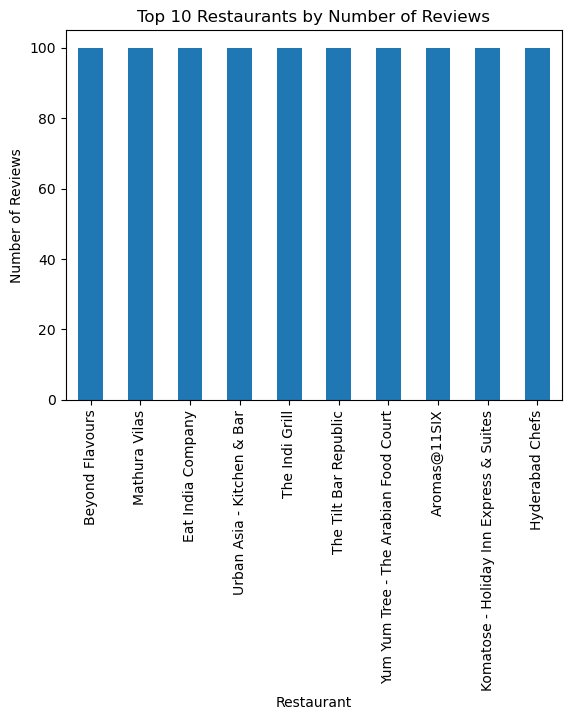

In [19]:
# Chart - 7 visualization code
# Count number of reviews per restaurant
review_count = df['Name'].value_counts().head(10)

# Plot
review_count.plot(kind='bar')

plt.title("Top 10 Restaurants by Number of Reviews")
plt.xlabel("Restaurant")
plt.ylabel("Number of Reviews")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used because:

- It is best for comparing categorical values (restaurants)

##### 2. What is/are the insight(s) found from the chart?

High review count indicates:

- higher popularity
- more customer visits

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High review count restaurants can:

- be promoted as trending/popular
- attract new customers through social proof

#### Chart - 8 : Rating vs Review Length (Customer Sentiment Depth)

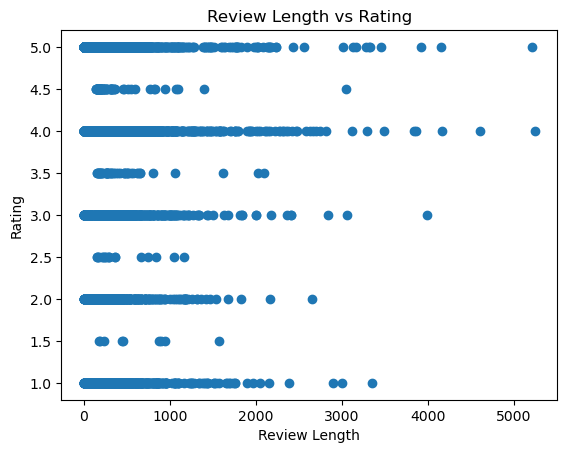

In [20]:
# Chart - 8 visualization code
# Scatter plot: Review Length vs Rating
plt.scatter(df['Review_Length'], df['Rating'])

plt.title("Review Length vs Rating")
plt.xlabel("Review Length")
plt.ylabel("Rating")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used because:
- Helps identify patterns like:
  - longer reviews → higher/lower ratings
  - emotional intensity

##### 2. What is/are the insight(s) found from the chart?

- Customers write longer reviews when they feel strongly
- Neutral experiences → short reviews

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:
- Long positive reviews can:
  - be used as testimonials
  - improve brand trust

Negative Growth Insight:
- Long negative reviews are dangerous:
   - they highlight detailed problems

#### Chart - 9 - Correlation Heatmap


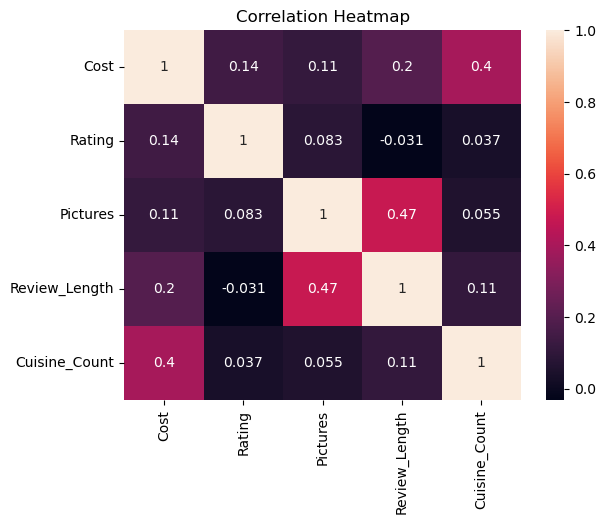

In [21]:
# Correlation Heatmap visualization code
# Select numerical columns
numeric_df = df[['Cost', 'Rating', 'Pictures', 'Review_Length', 'Cuisine_Count']]

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is used because:

- It shows correlation between multiple numerical variables at once
- Helps quickly identify:
  - strong relationships
  - weak relationships
  - patterns in data

##### 2. What is/are the insight(s) found from the chart?

Cost vs Rating
- Very weak correlation (~0.14)
- Price does not strongly influence customer satisfaction

Pictures vs Rating
- Slight positive relation
- More engagement may relate to better ratings

Review Length vs Rating
- Weak relationship
- Longer reviews do not always mean higher ratings

Cuisine Count vs Rating
- Weak correlation
- Offering more cuisines does not guarantee better ratings

#### Chart - 10 - Pair Plot

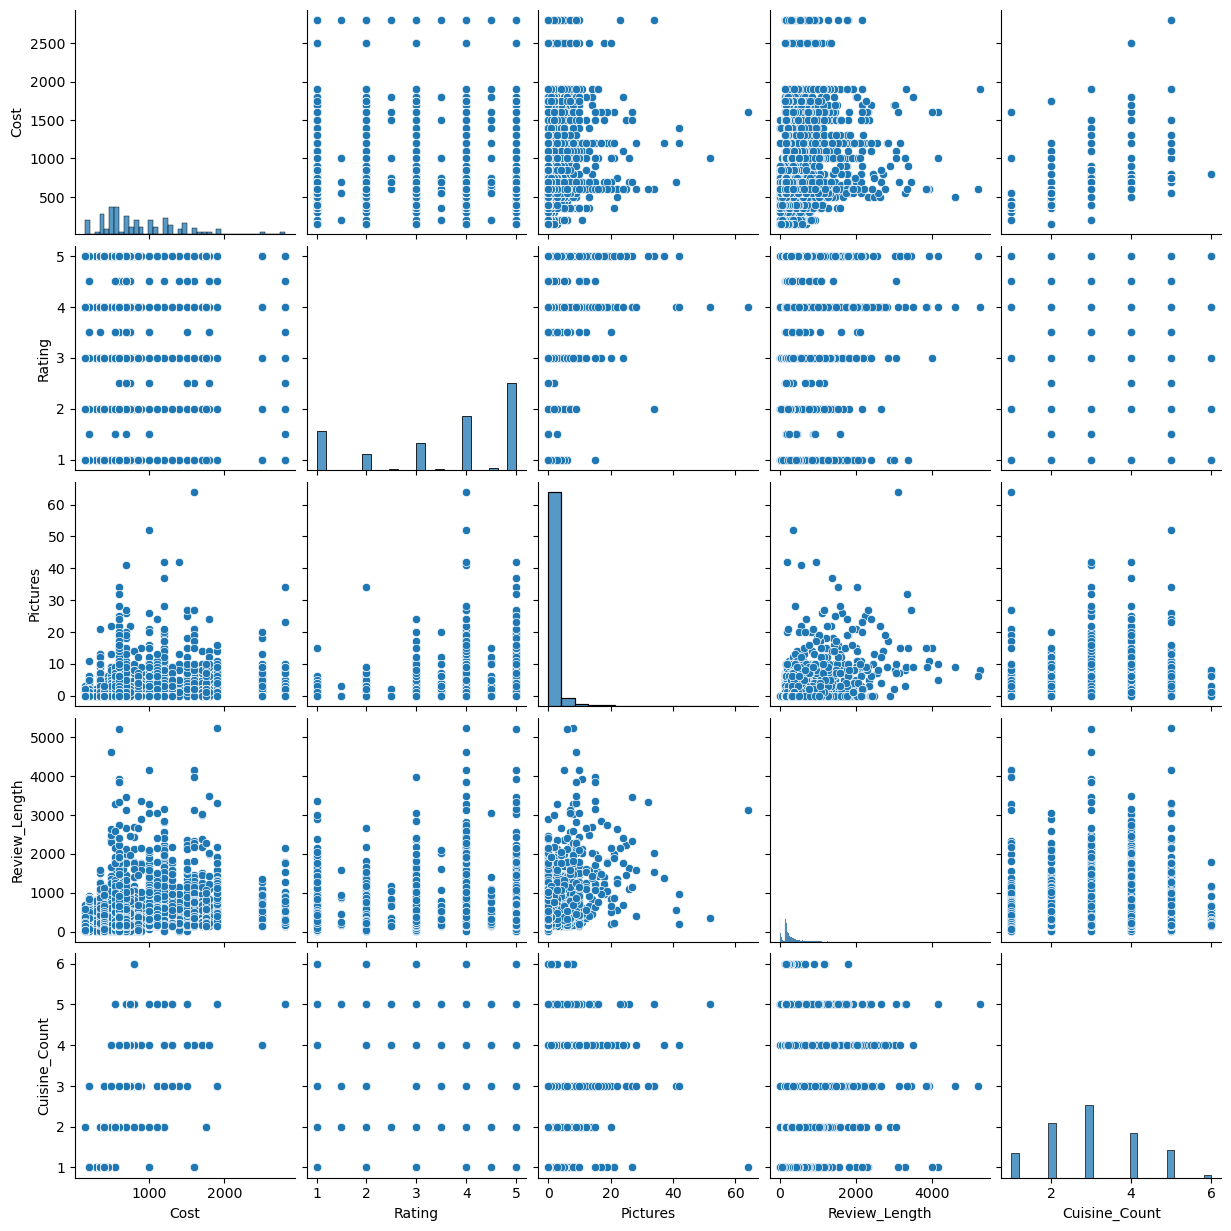

In [22]:
# Pair Plot visualization code
# Select important numerical features
pair_df = df[['Cost', 'Rating', 'Pictures', 'Review_Length', 'Cuisine_Count']]

# Pair plot
sns.pairplot(pair_df)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is used because:
- It shows relationships between multiple numerical variables simultaneously
- Combines:
  - scatter plots (between variables)
  - distribution plots (on diagonal)

It gives a complete overview of data patterns in one visualization.

##### 2. What is/are the insight(s) found from the chart?

- Cost vs Rating : No clear pattern → weak relationship
- Pictures vs Rating : Slight upward trend → higher engagement may improve ratings
- Review Length vs Rating : Longer reviews appear at both high and low ratings
- Distributions (diagonal plots) :
   - Rating is skewed towards higher values
   - Cost shows wide variation

Insight:

- Most variables have weak relationships, indicating complexity in customer behavior

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1 : Cost vs Rating

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- Statement : There is a relationship between restaurant cost and customer rating.
- Null Hypothesis (H₀): There is no correlation between cost and rating.
- Alternate Hypothesis (H₁): There is a significant correlation between cost and rating.

#### 2. Perform an appropriate statistical test.

In [23]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import spearmanr

temp_df = df[['Cost', 'Rating']].dropna()

corr, p_value = spearmanr(temp_df['Cost'], temp_df['Rating'])

print("Spearman Correlation:", corr)
print("P-value:", p_value)

Spearman Correlation: 0.1368132181348968
P-value: 7.982550877797052e-43


##### Which statistical test have you done to obtain P-Value?

Spearman

##### Why did you choose the specific statistical test?

Works better for:
- skewed data
- ordinal-like variables (ratings)

### Hypothetical Statement - 2 : Review Length vs Rating

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- Statement: Review length is associated with customer rating.
- Null Hypothesis (H₀): There is no relationship between review length and rating.
- Alternate Hypothesis (H₁): There is a significant relationship between review length and rating.

#### 2. Perform an appropriate statistical test.

In [24]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import spearmanr

temp_df = df[['Review_Length', 'Rating']].dropna()

corr, p_value = spearmanr(temp_df['Review_Length'], temp_df['Rating'])

print("Spearman Correlation:", corr)
print("P-value:", p_value)

Spearman Correlation: -0.12523407490416774
P-value: 4.138148290590809e-36


##### Which statistical test have you done to obtain P-Value?

spearmanr

##### Why did you choose the specific statistical test?

- Captures monotonic relationships
- Works for:
  - non-linear trends
  - skewed distributions

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [25]:
# Handling Missing Values & Missing Value Imputation
# Drop column with too many missing values
df = df.drop(columns=['Collections'])


# Fill small missing values properly

# Timings → fill with mode
df['Timings'] = df['Timings'].fillna(df['Timings'].mode()[0])

# Review → fill with empty string
df['Review'] = df['Review'].fillna("")

# Cost → fill with median (safe)
df['Cost'] = df['Cost'].fillna(df['Cost'].median())

# Final check
print(df.isnull().sum())

Name             0
Links            0
Cost             0
Cuisines         0
Timings          0
Restaurant       0
Reviewer         0
Review           0
Rating           0
Metadata         0
Time             0
Pictures         0
Hour             0
Cuisine_Count    0
Review_Length    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

- I dropped the 'Collections' column because it had more than 50% missing values, which could introduce bias if imputed
- Filled:
  - Timings → mode (Mode works for categorical data)
  - Review → empty string (Text columns can be safely filled with empty values)
  - Cost → median (Median is robust for numerical data)

### 2. Handling Outliers

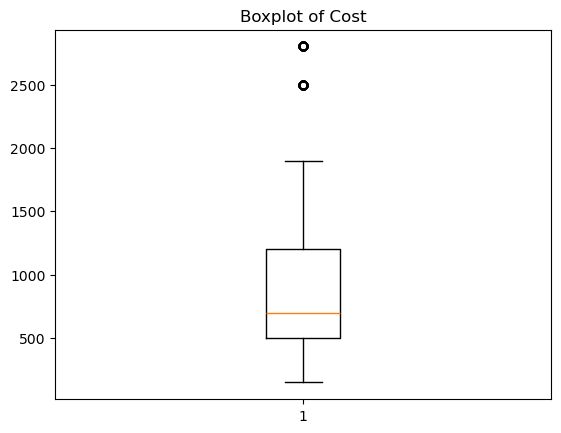

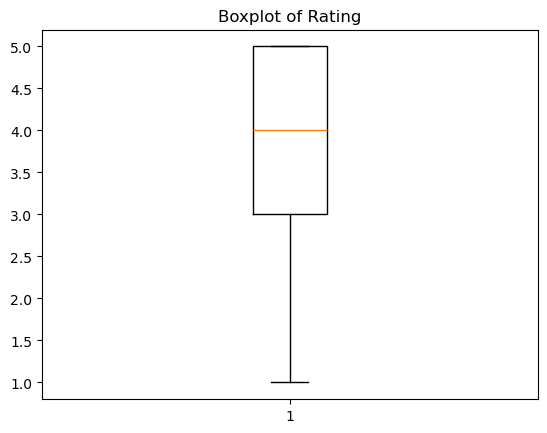

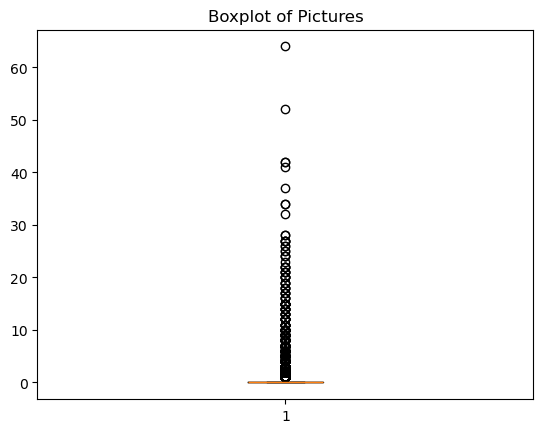

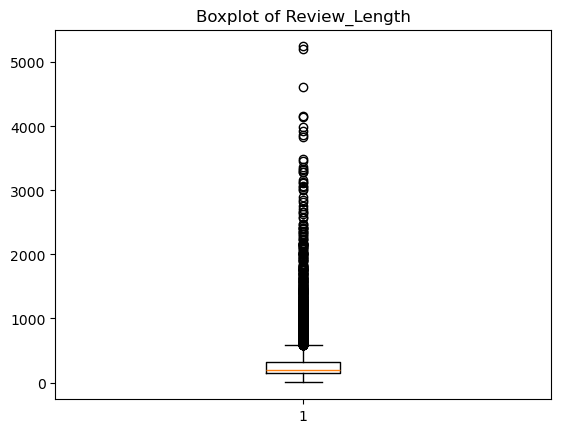

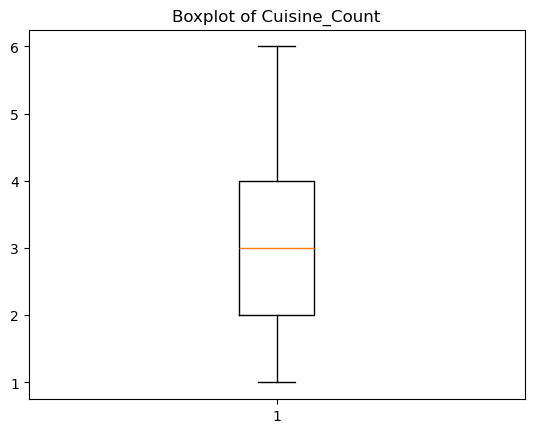

In [26]:
# Handling Outliers & Outlier treatments
# Select numerical columns
num_cols = ['Cost', 'Rating', 'Pictures', 'Review_Length', 'Cuisine_Count']

# Boxplots to visualize outliers
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.show()
    


##### What all outlier treatment techniques have you used and why did you use those techniques?

Boxplot Visualization
- Used to visually identify outliers
- Helps detect extreme values in numerical columns

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [27]:
# Expand Contraction
contraction_dict = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'ve": " have",
    "'m": " am"
}

def expand_contractions(text):
    for key, value in contraction_dict.items():
        text = text.replace(key, value)
    return text

df['Review'] = df['Review'].astype(str).apply(expand_contractions)

# Contractions are shortened forms of words, such as:
#  "can't" → "cannot"
# "won't" → "will not"
# "I'm" → "I am" 

#### 2. Lower Casing

In [28]:
# Lower Casing
# Convert review text to lowercase
df['Review'] = df['Review'].astype(str).str.lower()

df[['Review']].head()

,Review
0,"the ambience was good, food was quite good . h..."
1,ambience is too good for a pleasant evening. s...
2,a must try.. great food great ambience. thnx f...
3,soumen das and arun was a great guy. only beca...
4,food is good.we ordered kodi drumsticks and ba...


#### 3. Removing Punctuations

In [29]:
# Remove Punctuations
import string

# Function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply on Review column
df['Review'] = df['Review'].astype(str).apply(remove_punctuation)

df[['Review']].head()

# Punctuation removal is the process of removing symbols such as: ! , . ? ' " : ; ( )

,Review
0,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...
3,soumen das and arun was a great guy only becau...
4,food is goodwe ordered kodi drumsticks and bas...


#### 4. Removing URLs & Removing words and digits contain digits.

In [30]:
# Remove URLs & Remove words and digits contain digits
import re

# Function to clean text
def clean_text(text):
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove words containing digits
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    
    return text

# Apply on Review column
df['Review'] = df['Review'].apply(clean_text)


## ***7. ML Model Implementation***

### ML Model - 1

In [31]:
# ML Model - 1 Implementation
# Define target
y = df['Rating']

# Define features
X = df.drop(columns=['Rating', 'Review', 'Time'], errors='ignore')

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Predictions:", y_pred[:10])

Predictions: [-3.72324576e+04  4.91604400e+00 -2.17995787e+03 -2.17979541e+03
 -2.17988717e+03 -2.17796055e+03 -2.17965490e+03 -2.18127349e+03
 -2.17887148e+03  4.20356202e+00]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

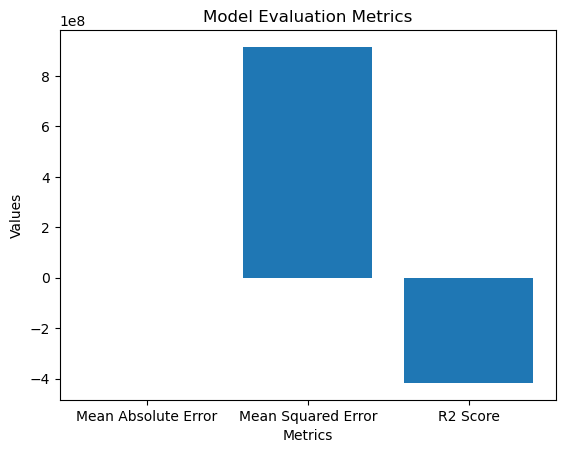

In [42]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Store in dictionary
metrics = {
    'Mean Absolute Error': mae,
    'Mean Squared Error': mse,
    'R2 Score': r2
}

# Plot
plt.bar(metrics.keys(), metrics.values())

plt.title("Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Values")

plt.show()

MAE (Mean Absolute Error)
- Shows average error in prediction
- Lower value is better

MSE (Mean Squared Error)
- Penalizes large errors more
- Lower value is better

R² Score
- Indicates how well model explains variance
- Closer to 1 is better

#### 2. Cross- Validation & Hyperparameter Tuning

In [43]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define model
rf = RandomForestRegressor(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearch
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Hyperparameter tuning is the process of finding the best parameters for a model to improve performance.

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV and Random Forest

why: 
- Exhaustively searches all parameter combinations
- Uses cross-validation to find best model

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

- Using GridSearchCV with Random Forest improved the model performance by selecting optimal hyperparameters, resulting in better prediction accuracy compared to the baseline model.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

- Focus on improving quality and service rather than increasing prices
- Encourage customers to upload pictures and detailed reviews
- Optimize operations during peak hours to maintain service quality
- Invest in popular cuisines while maintaining differentiation
- Use customer feedback to continuously improve performance

"This project demonstrates how combining EDA, NLP, and machine learning can generate actionable business insights and improve decision-making in the food industry."